
# 03 — Análise de $R_{AA}(p_T)$

Este notebook analisa o fator de modificação nuclear:

$$
R_{AA}(p_T)
$$

para píons, kaons e prótons em colisões Pb–Pb.

As tabelas usadas são:

- `Table15.csv`: $R_{AA}$ de píons;
- `Table16.csv`: $R_{AA}$ de kaons;
- `Table17.csv`: $R_{AA}$ de prótons.

A ideia física é comparar a produção em Pb–Pb com o baseline pp escalado pelo número esperado de colisões nucleon–nucleon.



## 1. O que $R_{AA}$ mede?

De forma conceitual:

$$
R_{AA}(p_T)
=
\frac{\text{produção em Pb--Pb}}
{\text{produção esperada se Pb--Pb fosse apenas uma soma de pp}}
$$

Então:

- $R_{AA}=1$: comportamento compatível com superposição incoerente de colisões pp;
- $R_{AA}<1$: supressão nuclear, típica de perda de energia no meio;
- $R_{AA}>1$: enhancement relativo, podendo aparecer em regiões influenciadas por efeitos coletivos, recombination ou outros mecanismos.

No setor high-$p_T$, $R_{AA}<1$ é a assinatura clássica de jet quenching.


## 2. Imports, diretórios e parser

In [18]:

from pathlib import Path
import csv
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

DATA_DIR = Path("..")
PB_PB_DIR = DATA_DIR / "Pb-Pb vs pp"

if not PB_PB_DIR.exists():
    PB_PB_DIR = Path(".")


def split_hepdata_blocks(path):
    """
    Parser no mesmo estilo dos notebooks anteriores.
    Lê um CSV HEPData com múltiplos blocos e retorna:
        [(metadata, dataframe), ...]
    """
    path = Path(path)
    lines = path.read_text(encoding="utf-8").splitlines()

    blocks = []
    meta = {}
    header = None
    rows = []

    def flush_block():
        nonlocal header, rows
        if header is not None and rows:
            df = pd.DataFrame(rows, columns=header)

            for col in df.columns:
                converted = pd.to_numeric(df[col], errors="coerce")
                if converted.notna().mean() > 0.5:
                    df[col] = converted

            blocks.append((meta.copy(), df))

        header = None
        rows = []

    for raw in lines:
        line = raw.strip()

        if not line:
            continue

        if line.startswith("#:"):
            content = line[2:].strip()

            if "CENTRALITY" in content and header is not None and rows:
                flush_block()

            if ",,," in content:
                key, value = content.split(",,,", 1)
                meta[key.strip()] = value.strip()
            elif ":" in content:
                key, value = content.split(":", 1)
                meta[key.strip()] = value.strip()
            elif "," in content:
                parts = next(csv.reader([content]))
                if parts:
                    meta[parts[0].strip()] = " | ".join(p.strip() for p in parts[1:])

            continue

        parts = [p.strip() for p in next(csv.reader([line]))]

        if header is not None and rows:
            first = parts[0]
            if any(ch.isalpha() for ch in first) or "$" in first:
                flush_block()

        if header is None:
            header = parts
        else:
            if len(parts) == len(header):
                rows.append(parts)

    flush_block()
    return blocks


def centrality_midpoint(label):
    nums = re.findall(r"\d+\.?\d*", str(label))
    if len(nums) >= 2:
        return 0.5 * (float(nums[0]) + float(nums[1]))
    return np.nan


def get_centrality(meta):
    return meta.get("CENTRALITY [pct]", "unknown")


def get_pt(df):
    pt_col = [c for c in df.columns if "p_{T}" in c and "LOW" not in c and "HIGH" not in c][0]
    return df[pt_col].values


def get_observable_col(df):
    excluded = ["p_{T}", "LOW", "HIGH", "stat", "syst"]
    candidates = [
        c for c in df.columns
        if not any(e in c for e in excluded)
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    if not candidates:
        raise ValueError("Não encontrei coluna de observável.")
    return candidates[0]


def get_errors(df):
    stat = df["stat. +"].values if "stat. +" in df.columns else None
    syst = df["syst. +"].values if "syst. +" in df.columns else None
    uncorr = df["syst. uncorr. +"].values if "syst. uncorr. +" in df.columns else None
    return stat, syst, uncorr


def load_table(name):
    path = PB_PB_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Não encontrei {path}. Ajuste PB_PB_DIR.")
    return split_hepdata_blocks(path)


def summarize_blocks(blocks, table_name):
    print(f"{table_name}: {len(blocks)} blocos")
    print("Centralidades:", [get_centrality(meta) for meta, _ in blocks])


def normalize_cent_label(label):
    nums = re.findall(r"\d+\.?\d*", str(label))
    if len(nums) >= 2:
        return f"{float(nums[0]):.1f}-{float(nums[1]):.1f}"
    return str(label)


def select_blocks_by_centrality(
    blocks,
    wanted=("0.0-5.0", "30.0-40.0", "70.0-80.0")
):
    wanted_norm = {normalize_cent_label(w) for w in wanted}

    selected = []
    for meta, df in blocks:
        cent = get_centrality(meta)
        cent_norm = normalize_cent_label(cent)

        if cent_norm in wanted_norm:
            selected.append((meta, df))

    return selected


## 3. Carregar tabelas de $R_{AA}$

In [19]:

# =========================
# Tabelas de R_AA
# =========================

raa_pion_blocks = load_table("Table15.csv")    # R_AA de pions
raa_kaon_blocks = load_table("Table16.csv")    # R_AA de kaons
raa_proton_blocks = load_table("Table17.csv")  # R_AA de protons

summarize_blocks(raa_pion_blocks, "Table15 — pion R_AA")
summarize_blocks(raa_kaon_blocks, "Table16 — kaon R_AA")
summarize_blocks(raa_proton_blocks, "Table17 — proton R_AA")


Table15 — pion R_AA: 12 blocos
Centralidades: ['0-5', '5-10', '10-20', '20-40', '40-60', '60-80', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
Table16 — kaon R_AA: 12 blocos
Centralidades: ['0-5', '5-10', '10-20', '20-40', '40-60', '60-80', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
Table17 — proton R_AA: 12 blocos
Centralidades: ['0-5', '5-10', '10-20', '20-40', '40-60', '60-80', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']



## 4. $R_{AA}$ dos píons

Os píons são a espécie mais abundante. Em alto $p_T$, eles são muito importantes para enxergar supressão de partículas produzidas por fragmentação de partons duros.

Se $R_{AA}<1$, isso indica que a produção em Pb–Pb é menor do que a esperada a partir de pp escalado, sugerindo perda de energia no QGP.


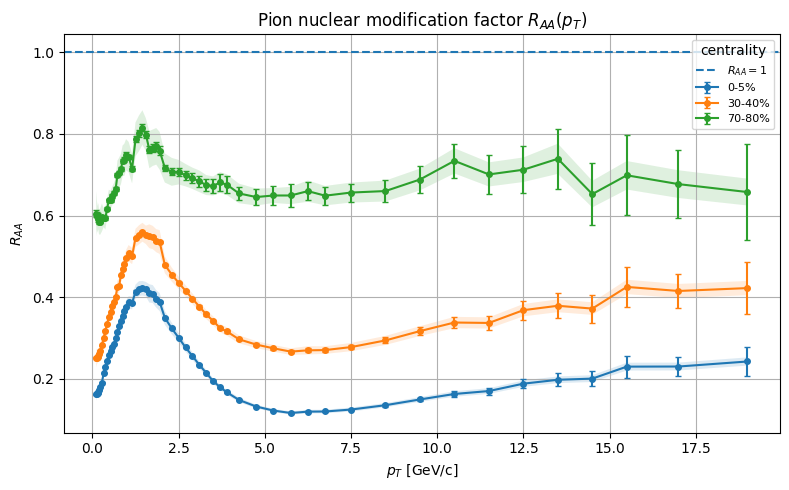

In [20]:

def plot_raa_species(blocks, species_label, title, wanted=("0.0-5.0", "30.0-40.0", "70.0-80.0")):
    selected = select_blocks_by_centrality(blocks, wanted)

    fig, ax = plt.subplots(figsize=(8,5))

    for meta, df in selected:
        cent = get_centrality(meta)
        pt = get_pt(df)
        y_col = get_observable_col(df)
        y = df[y_col].values
        stat, syst, uncorr = get_errors(df)

        if syst is not None:
            ax.fill_between(
                pt,
                y - syst,
                y + syst,
                alpha=0.15,
            )

        ax.errorbar(
            pt,
            y,
            yerr=stat,
            fmt="o-",
            capsize=2,
            linewidth=1.5,
            markersize=4,
            label=f"{cent}%",
        )

    ax.axhline(1.0, linestyle="--", linewidth=1.5, label=r"$R_{AA}=1$")
    ax.set_xlabel(r"$p_T$ [GeV/c]")
    ax.set_ylabel(r"$R_{AA}$")
    ax.set_title(title)
    ax.grid(True)
    ax.legend(title="centrality", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_raa_species(
    raa_pion_blocks,
    r"$\pi^+ + \pi^-$",
    r"Pion nuclear modification factor $R_{AA}(p_T)$"
)



## 5. $R_{AA}$ de kaons e prótons

Agora repetimos para kaons e prótons.

Comparar espécies diferentes é importante porque a física muda com:

- massa;
- conteúdo de quarks;
- méson versus bárion;
- recombination/coalescence;
- fragmentação em alto $p_T$.


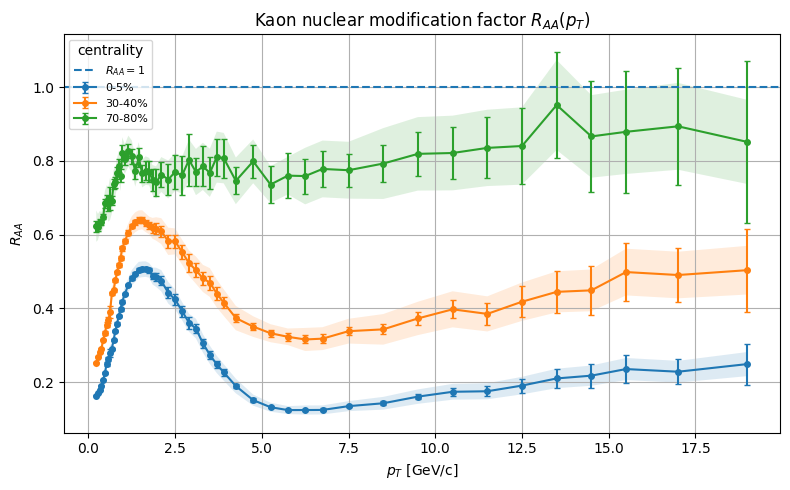

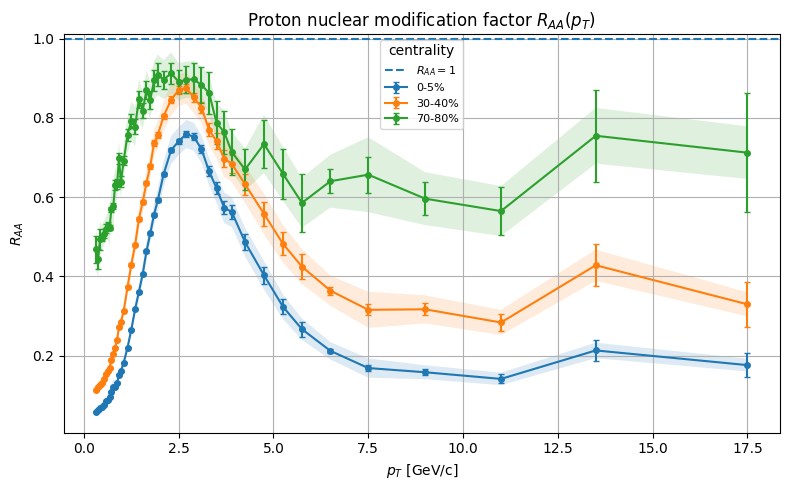

In [21]:

plot_raa_species(
    raa_kaon_blocks,
    r"$K^+ + K^-$",
    r"Kaon nuclear modification factor $R_{AA}(p_T)$"
)

plot_raa_species(
    raa_proton_blocks,
    r"$p+\bar p$",
    r"Proton nuclear modification factor $R_{AA}(p_T)$"
)



## 6. Comparação de espécies na mesma centralidade

Aqui fixamos a centralidade e comparamos $\pi$, $K$ e $p$.

Essa comparação ajuda a separar:

- efeitos universais de jet quenching em alto $p_T$;
- efeitos específicos de espécie em $p_T$ intermediário;
- bump bariônico/protônico associado a coletividade e coalescence.


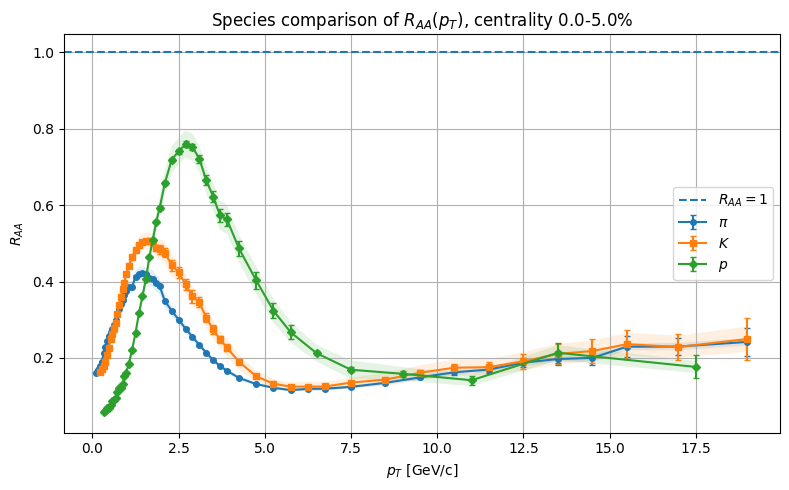

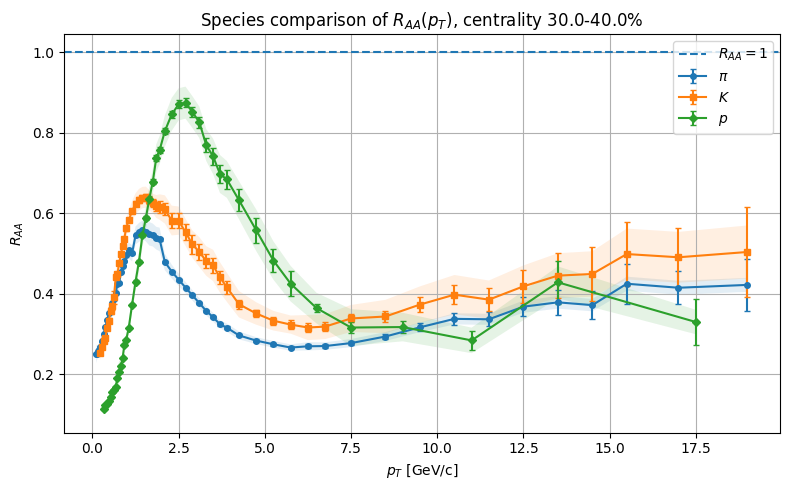

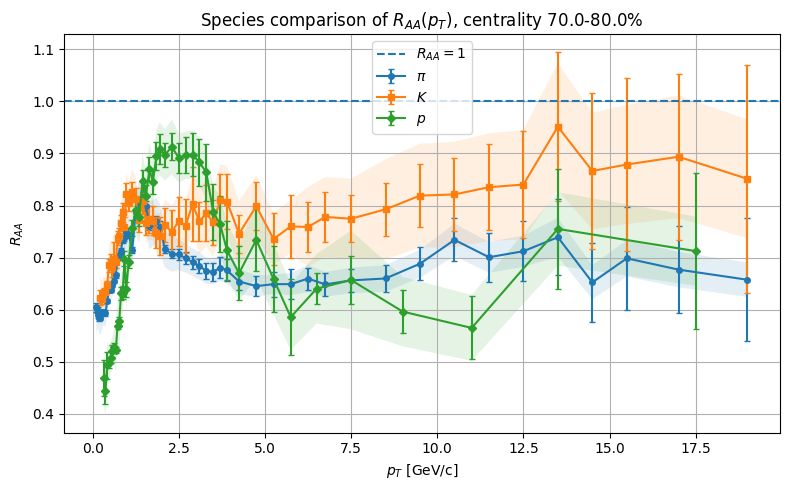

In [23]:
def normalize_cent_label(label):
    nums = re.findall(r"\d+\.?\d*", str(label))
    if len(nums) >= 2:
        return f"{float(nums[0]):.1f}-{float(nums[1]):.1f}"
    return str(label)


def get_block_by_centrality(blocks, cent_label):
    target = normalize_cent_label(cent_label)

    for meta, df in blocks:
        cent = get_centrality(meta)
        if normalize_cent_label(cent) == target:
            return meta, df

    available = [get_centrality(meta) for meta, _ in blocks]
    raise ValueError(
        f"Centralidade {cent_label} não encontrada. Disponíveis: {available}"
    )


def plot_raa_species_comparison(cent_label="0.0-5.0"):
    fig, ax = plt.subplots(figsize=(8,5))

    species_data = [
        (raa_pion_blocks, r"$\pi$", "o-"),
        (raa_kaon_blocks, r"$K$", "s-"),
        (raa_proton_blocks, r"$p$", "D-"),
    ]

    for blocks, label, marker in species_data:
        meta, df = get_block_by_centrality(blocks, cent_label)

        pt = get_pt(df)
        y_col = get_observable_col(df)
        y = df[y_col].values
        stat, syst, _ = get_errors(df)

        if syst is not None:
            ax.fill_between(pt, y - syst, y + syst, alpha=0.12)

        ax.errorbar(
            pt,
            y,
            yerr=stat,
            fmt=marker,
            capsize=2,
            linewidth=1.5,
            markersize=4,
            label=label,
        )

    ax.axhline(1.0, linestyle="--", linewidth=1.5, label=r"$R_{AA}=1$")
    ax.set_xlabel(r"$p_T$ [GeV/c]")
    ax.set_ylabel(r"$R_{AA}$")
    ax.set_title(
        rf"Species comparison of $R_{{AA}}(p_T)$, centrality {normalize_cent_label(cent_label)}%"
    )
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_raa_species_comparison("0-5")
plot_raa_species_comparison("30-40")
plot_raa_species_comparison("70-80")


## 7. Scan de centralidade em $p_T$ fixo

Agora pegamos um valor aproximado de $p_T$ e observamos como $R_{AA}$ muda com a centralidade.

A expectativa física é:

- colisões centrais: meio maior e mais denso, supressão mais forte;
- colisões periféricas: meio menor, comportamento mais próximo de pp.


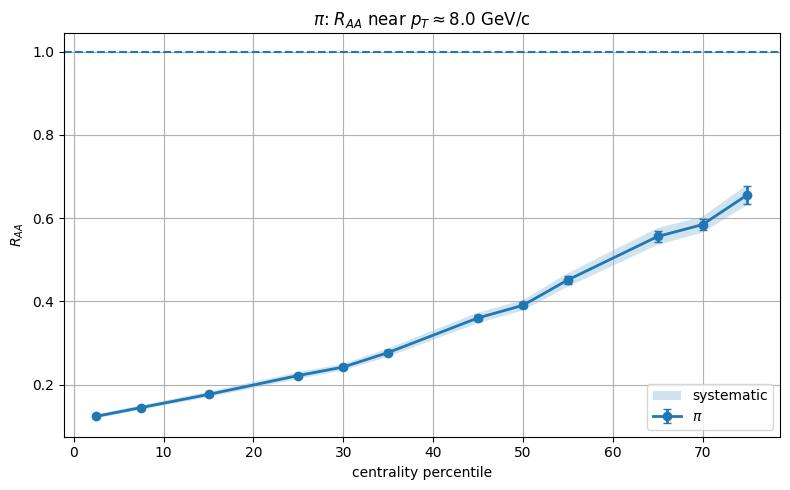

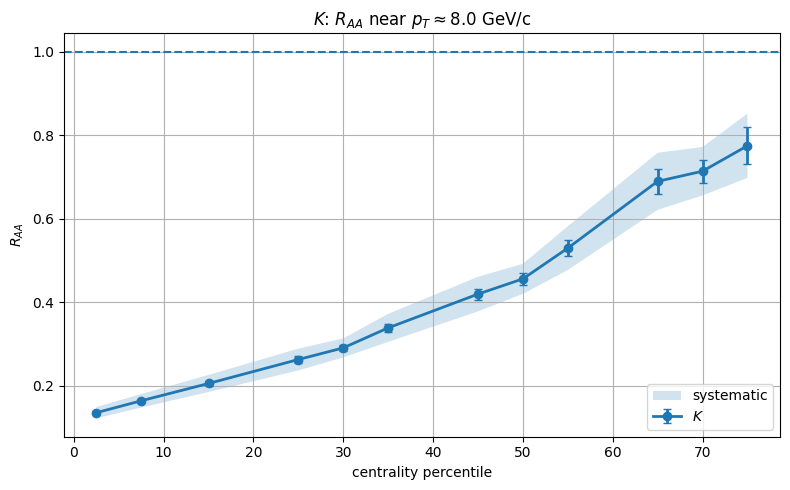

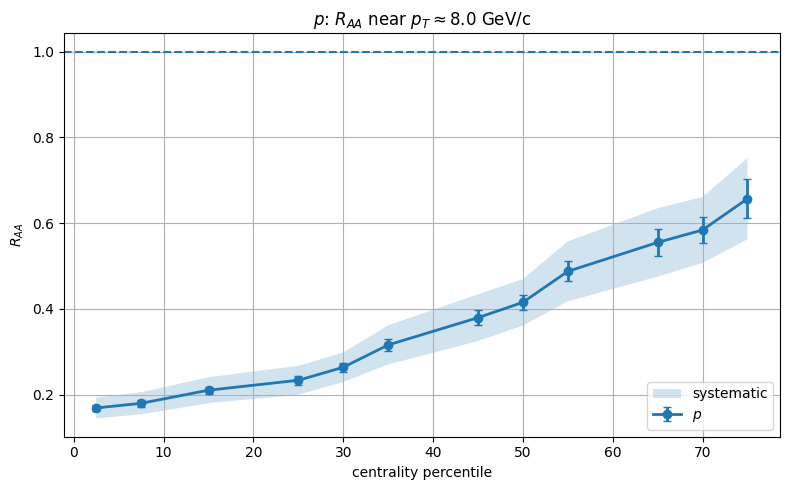

In [8]:

def plot_raa_at_fixed_pt(blocks, species_label, pt_target=8.0):
    cents = []
    values = []
    stats = []
    systs = []

    for meta, df in blocks:
        cent = get_centrality(meta)
        cent_mid = centrality_midpoint(cent)

        pt = get_pt(df)
        y_col = get_observable_col(df)
        y = df[y_col].values
        stat, syst, _ = get_errors(df)

        idx = np.argmin(np.abs(pt - pt_target))

        cents.append(cent_mid)
        values.append(y[idx])
        stats.append(stat[idx] if stat is not None else 0)
        systs.append(syst[idx] if syst is not None else 0)

    cents = np.array(cents)
    values = np.array(values)
    stats = np.array(stats)
    systs = np.array(systs)

    order = np.argsort(cents)

    fig, ax = plt.subplots(figsize=(8,5))

    ax.fill_between(
        cents[order],
        values[order] - systs[order],
        values[order] + systs[order],
        alpha=0.2,
        label="systematic",
    )

    ax.errorbar(
        cents[order],
        values[order],
        yerr=stats[order],
        fmt="o-",
        capsize=3,
        linewidth=2,
        label=species_label,
    )

    ax.axhline(1.0, linestyle="--", linewidth=1.5)
    ax.set_xlabel("centrality percentile")
    ax.set_ylabel(r"$R_{AA}$")
    ax.set_title(rf"{species_label}: $R_{{AA}}$ near $p_T \approx {pt_target}$ GeV/c")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_raa_at_fixed_pt(raa_pion_blocks, r"$\pi$", pt_target=8.0)
plot_raa_at_fixed_pt(raa_kaon_blocks, r"$K$", pt_target=8.0)
plot_raa_at_fixed_pt(raa_proton_blocks, r"$p$", pt_target=8.0)



## 8. Leitura física inicial

O papel de $R_{AA}$ é tornar explícita a comparação com pp.

Nos espectros absolutos, Pb–Pb central sempre tem muito mais partículas porque o sistema é maior. Mas isso não nos diz, sozinho, se houve modificação do meio.

$R_{AA}$ remove essa expectativa geométrica básica e pergunta:

> a produção observada em Pb–Pb é compatível com uma simples soma de colisões pp?

Quando a resposta é não, especialmente em alto $p_T$, temos evidência de que os partons duros interagiram com o QGP antes de hadronizar.

Assim:

- espectros $dN/dp_T$: mostram a produção final;
- razões $K/\pi$, $p/\pi$: mostram composição hadrônica;
- $R_{AA}$: mostra modificação nuclear relativa ao baseline pp.
